# Exp 1 — CatBoost instead of XGBoost (CP-CNN)

Controlled experiment against `baseline_0`: **exactly one change** — every XGBoost model
(the binary classifiers in `classifier/classify.py` and the continuous regressors in
`classifier/regression.py`) is replaced with a CatBoost equivalent, translating
hyperparameters 1:1 (objective/loss, n_estimators/iterations, learning_rate,
scale_pos_weight). Everything else is identical to baseline_0 and is *not*
recomputed here:

- Same input profiles (`mad_featselect.parquet`), same DMSO-anchored preprocessing.
- Same GMD distances and POD curves (`pods.parquet`, `ccpods.parquet`, etc.) — these
  don't involve a classifier/regressor at all, so baseline_0's cached files under
  `1_snakemake/outputs/cpcnn/mad_featselect/` are read directly, not regenerated.
- Same profile aggregation (`agg.parquet`) and axiom hitcalls (`axiom_hits.parquet`).
- Same 5-fold `StratifiedKFold` split for classifiers, same 10x `GroupShuffleSplit`
  (grouped by `Metadata_Compound`) for regression.
- Same 3 classifier `Model_type`s (`Actual` / `Random_baseline` / `Cellcount_baseline`)
  and 3 regression `Model_type`s (`Morphology` / `Baseline` / `Mean_predictor`).
- Same evaluation metrics, computed by the *same shared function*
  (`experiment_utils.compile_classifier_metrics` / `summarize_regression_metrics`) that
  baseline_0 uses internally — not a reimplementation, so "same evaluation metrics" is
  guaranteed by shared code rather than two notebooks merely looking alike.

The model-swap code lives in `3_experiments/catboost_models.py` (a line-for-line mirror
of `classify.py`/`regression.py` with the estimator swapped) — see that file's
docstring for the CPU-vs-GPU benchmark that decided this experiment runs on CPU
(CatBoost's GPU path has per-model CUDA-init overhead that dominates for the many
small models this pipeline trains; XGBoost's GPU path did not have this problem).

**One more explicit, disclosed choice:** CatBoost auto-selects `boosting_type="Ordered"`
on data this size — a permutation-driven scheme with no XGBoost equivalent, benchmarked
here at ~6.5x slower per fit (52.4s vs 8.1s for one fit) than `"Plain"` boosting, which
would put the full classifier run at ~6h instead of ~1h. This experiment explicitly sets
`boosting_type="Plain"` for a closer "same gradient-boosting recipe, different library"
comparison — worth flagging in the dissertation as a deliberate deviation from CatBoost's
factory defaults, not an oversight.

## 0. Setup — reuse baseline_0's config and cached upstream outputs

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path("/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS")
SNAKE_DIR = REPO_ROOT / "1_snakemake"
EXP_DIR = REPO_ROOT / "3_experiments"
EXP_NAME = "exp_1"
EXP_OUT = EXP_DIR / "outputs" / EXP_NAME
(EXP_OUT / "metrics").mkdir(parents=True, exist_ok=True)
(EXP_OUT / "classifier_results").mkdir(parents=True, exist_ok=True)
(EXP_OUT / "figures").mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SNAKE_DIR))
sys.path.insert(0, str(EXP_DIR))

import polars as pl
import experiment_utils as eu
import catboost_models as cbm

# Same canonical pipeline outputs baseline_0 produced -- read-only from here on.
OUT = SNAKE_DIR / "outputs/cpcnn/mad_featselect"
ANNOT = SNAKE_DIR / "inputs/annotations"

mad_featselect_path = OUT / "profiles/mad_featselect.parquet"
pods_path = OUT / "curves/pods.parquet"
agg_path = OUT / "aggregated_profiles/agg.parquet"
axiom_hits_path = OUT / "curves/axiom_hits.parquet"

for p in [mad_featselect_path, pods_path, agg_path, axiom_hits_path]:
    assert p.exists(), f"missing baseline_0 output: {p} -- run baseline_0.ipynb first"

print("Reusing baseline_0's cached upstream outputs (unchanged by this experiment):")
for p in [mad_featselect_path, pods_path, agg_path, axiom_hits_path]:
    print(f"  {p.relative_to(SNAKE_DIR)}")


Reusing baseline_0's cached upstream outputs (unchanged by this experiment):
  outputs/cpcnn/mad_featselect/profiles/mad_featselect.parquet
  outputs/cpcnn/mad_featselect/curves/pods.parquet
  outputs/cpcnn/mad_featselect/aggregated_profiles/agg.parquet
  outputs/cpcnn/mad_featselect/curves/axiom_hits.parquet


/scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/axiom-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Binary classifiers — CatBoost

Mirrors `classify.predict_binary`, called once per outcome type exactly like baseline_0's
Stage 5, but via `catboost_models.predict_binary_catboost`. Results are written to this
experiment's own `classifier_results/` (not baseline_0's) since these are new, separate
predictions.

In [2]:
BINARY_JOBS = [
    ("toxcast_cellbased", ANNOT / "toxcast_cellbased_binary.parquet"),
    ("toxcast_cellfree", ANNOT / "toxcast_cellfree_binary.parquet"),
    ("toxcast_cytotox", ANNOT / "toxcast_cytotox_binary.parquet"),
    ("axiom", axiom_hits_path),
]

binary_pred_paths = {}
for job_name, label_path in BINARY_JOBS:
    out_path = EXP_OUT / f"classifier_results/{job_name}_binary_predictions.parquet"
    if out_path.exists():
        print(f"[skip] {out_path.relative_to(EXP_DIR)}")
    else:
        print(f"[run]  {out_path.relative_to(EXP_DIR)} (CPU, {cbm.cpu_worker_count()}-way parallel)")
        cbm.predict_binary_catboost(str(agg_path), str(label_path), str(out_path))
    binary_pred_paths[job_name] = out_path


[skip] outputs/exp_1/classifier_results/toxcast_cellbased_binary_predictions.parquet
[skip] outputs/exp_1/classifier_results/toxcast_cellfree_binary_predictions.parquet
[skip] outputs/exp_1/classifier_results/toxcast_cytotox_binary_predictions.parquet
[skip] outputs/exp_1/classifier_results/axiom_binary_predictions.parquet


## 2. Continuous regression — CatBoost

Mirrors `regression.predict_axiom_assays`, called exactly like baseline_0's Stage 6, but
via `catboost_models.predict_axiom_assays_catboost`.

In [3]:
axiom_cont_pred_path = EXP_OUT / "classifier_results/axiom_continuous_predictions.parquet"
axiom_cont_metrics_path = EXP_OUT / "classifier_results/axiom_continuous_metrics.parquet"

if axiom_cont_pred_path.exists() and axiom_cont_metrics_path.exists():
    print(f"[skip] {axiom_cont_pred_path.relative_to(EXP_DIR)}")
    print(f"[skip] {axiom_cont_metrics_path.relative_to(EXP_DIR)}")
else:
    print(f"[run]  {axiom_cont_pred_path.relative_to(EXP_DIR)}")
    cbm.predict_axiom_assays_catboost(str(mad_featselect_path), str(axiom_cont_pred_path), str(axiom_cont_metrics_path))


[skip] outputs/exp_1/classifier_results/axiom_continuous_predictions.parquet
[skip] outputs/exp_1/classifier_results/axiom_continuous_metrics.parquet


## 3. Compile evaluation metrics

Calls the exact same functions baseline_0 uses internally (`experiment_utils.compile_classifier_metrics`,
`experiment_utils.summarize_regression_metrics`) -- same AUROC/PRAUC computation, same R²/RMSE/MAE
aggregation, same output schema, just pointed at this experiment's predictions.

In [4]:
classifier_metrics_path = EXP_OUT / f"metrics/{EXP_NAME}_classifier_metrics.parquet"
classifier_metrics = eu.compile_classifier_metrics(binary_pred_paths, classifier_metrics_path, feat_type="cpcnn")
print(f"Saved: {classifier_metrics_path}")
classifier_metrics.sort(["Outcome_type", "Metadata_AggType", "Model_type"]).head(20)


Saved: /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/3_experiments/outputs/exp_1/metrics/exp_1_classifier_metrics.parquet


Metadata_AggType,Metadata_Label,Model_type,AUROC,PRAUC,Metadata_Count_0,Metadata_Count_1,Outcome_type,Feat_type
str,str,str,f64,f64,i32,i32,str,str
"""all""","""MTT""","""Actual""",0.856837,0.829525,589,378,"""axiom""","""cpcnn"""
"""all""","""cell_count""","""Actual""",0.950881,0.839604,769,198,"""axiom""","""cpcnn"""
"""all""","""LDH""","""Actual""",0.930249,0.750693,840,127,"""axiom""","""cpcnn"""
"""all""","""LDH""","""Cellcount_base…",0.773964,0.457906,840,127,"""axiom""","""cpcnn"""
"""all""","""cell_count""","""Cellcount_base…",0.800912,0.60322,769,198,"""axiom""","""cpcnn"""
"""all""","""MTT""","""Cellcount_base…",0.698801,0.661168,589,378,"""axiom""","""cpcnn"""
"""all""","""LDH""","""Random_baselin…",0.468345,0.118985,840,127,"""axiom""","""cpcnn"""
"""all""","""cell_count""","""Random_baselin…",0.476632,0.196677,769,198,"""axiom""","""cpcnn"""
"""all""","""MTT""","""Random_baselin…",0.523504,0.405422,589,378,"""axiom""","""cpcnn"""


In [5]:
reg_metrics = pl.read_parquet(axiom_cont_metrics_path)

regression_metrics_path = EXP_OUT / f"metrics/{EXP_NAME}_regression_metrics.parquet"
regression_summary = eu.summarize_regression_metrics(reg_metrics, regression_metrics_path)
print(f"Saved: {regression_metrics_path}")
regression_summary


Saved: /scratch/mb03653/Dissertation/2024_09_09_Axiom_OASIS/3_experiments/outputs/exp_1/metrics/exp_1_regression_metrics.parquet


Variable_Name,Model_type,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std
str,str,f64,f64,f64,f64,f64,f64
"""Metadata_ldh_r…","""Baseline""",0.655511,0.052822,0.058783,0.005191,0.03573,0.00093
"""Metadata_ldh_r…","""Mean_predictor…",-0.002046,0.001966,0.100922,0.010558,0.060572,0.00296
"""Metadata_ldh_r…","""Morphology""",0.709644,0.048044,0.053757,0.002012,0.036661,0.000708
"""Metadata_mtt_r…","""Baseline""",0.727627,0.049557,0.088301,0.004896,0.046364,0.00124
"""Metadata_mtt_r…","""Mean_predictor…",-0.00191,0.001721,0.17099,0.014188,0.091856,0.004399
"""Metadata_mtt_r…","""Morphology""",0.820374,0.03202,0.071746,0.003532,0.03819,0.001284


## 4. Visualizations — exp_1 alone, then head-to-head vs baseline_0

Same plotting functions as baseline_0's Stage 8. The last two figures are the point of
this whole exercise: `baseline_0` and `exp_1` plotted side by side.

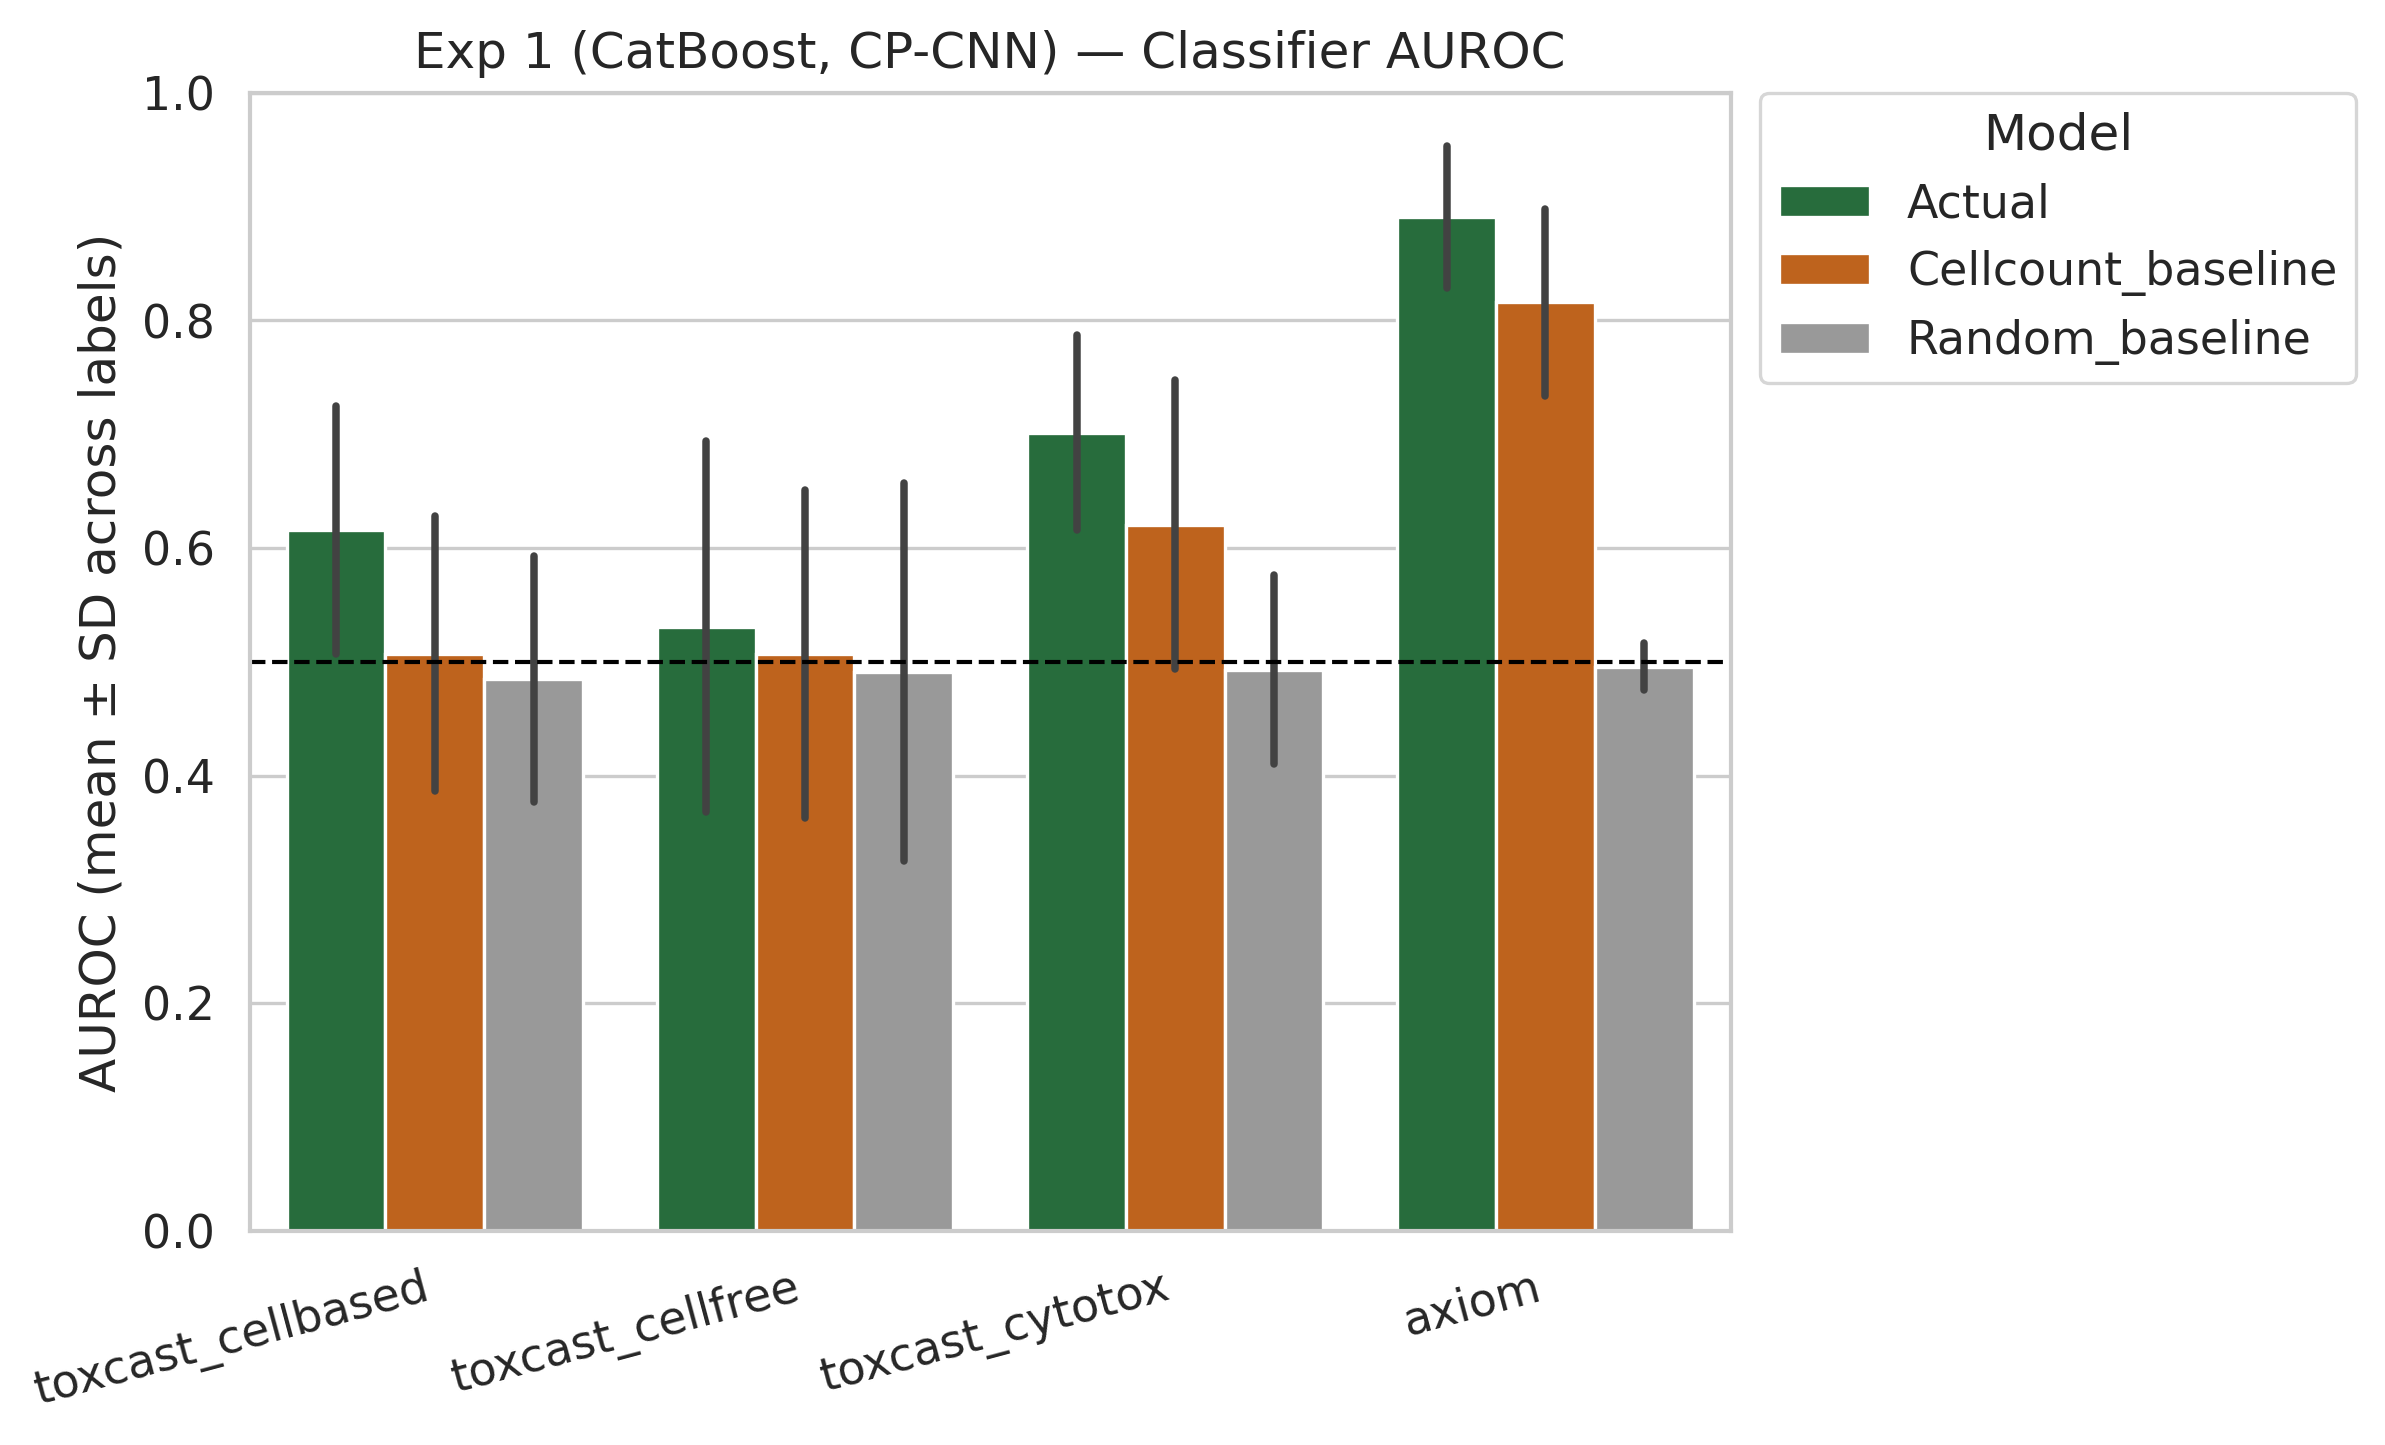

In [6]:
FIG = EXP_OUT / "figures"

p = eu.plot_classifier_auroc_summary(classifier_metrics, FIG / "classifier_auroc_summary", "Exp 1 (CatBoost, CP-CNN) — Classifier AUROC")
eu.show(p)


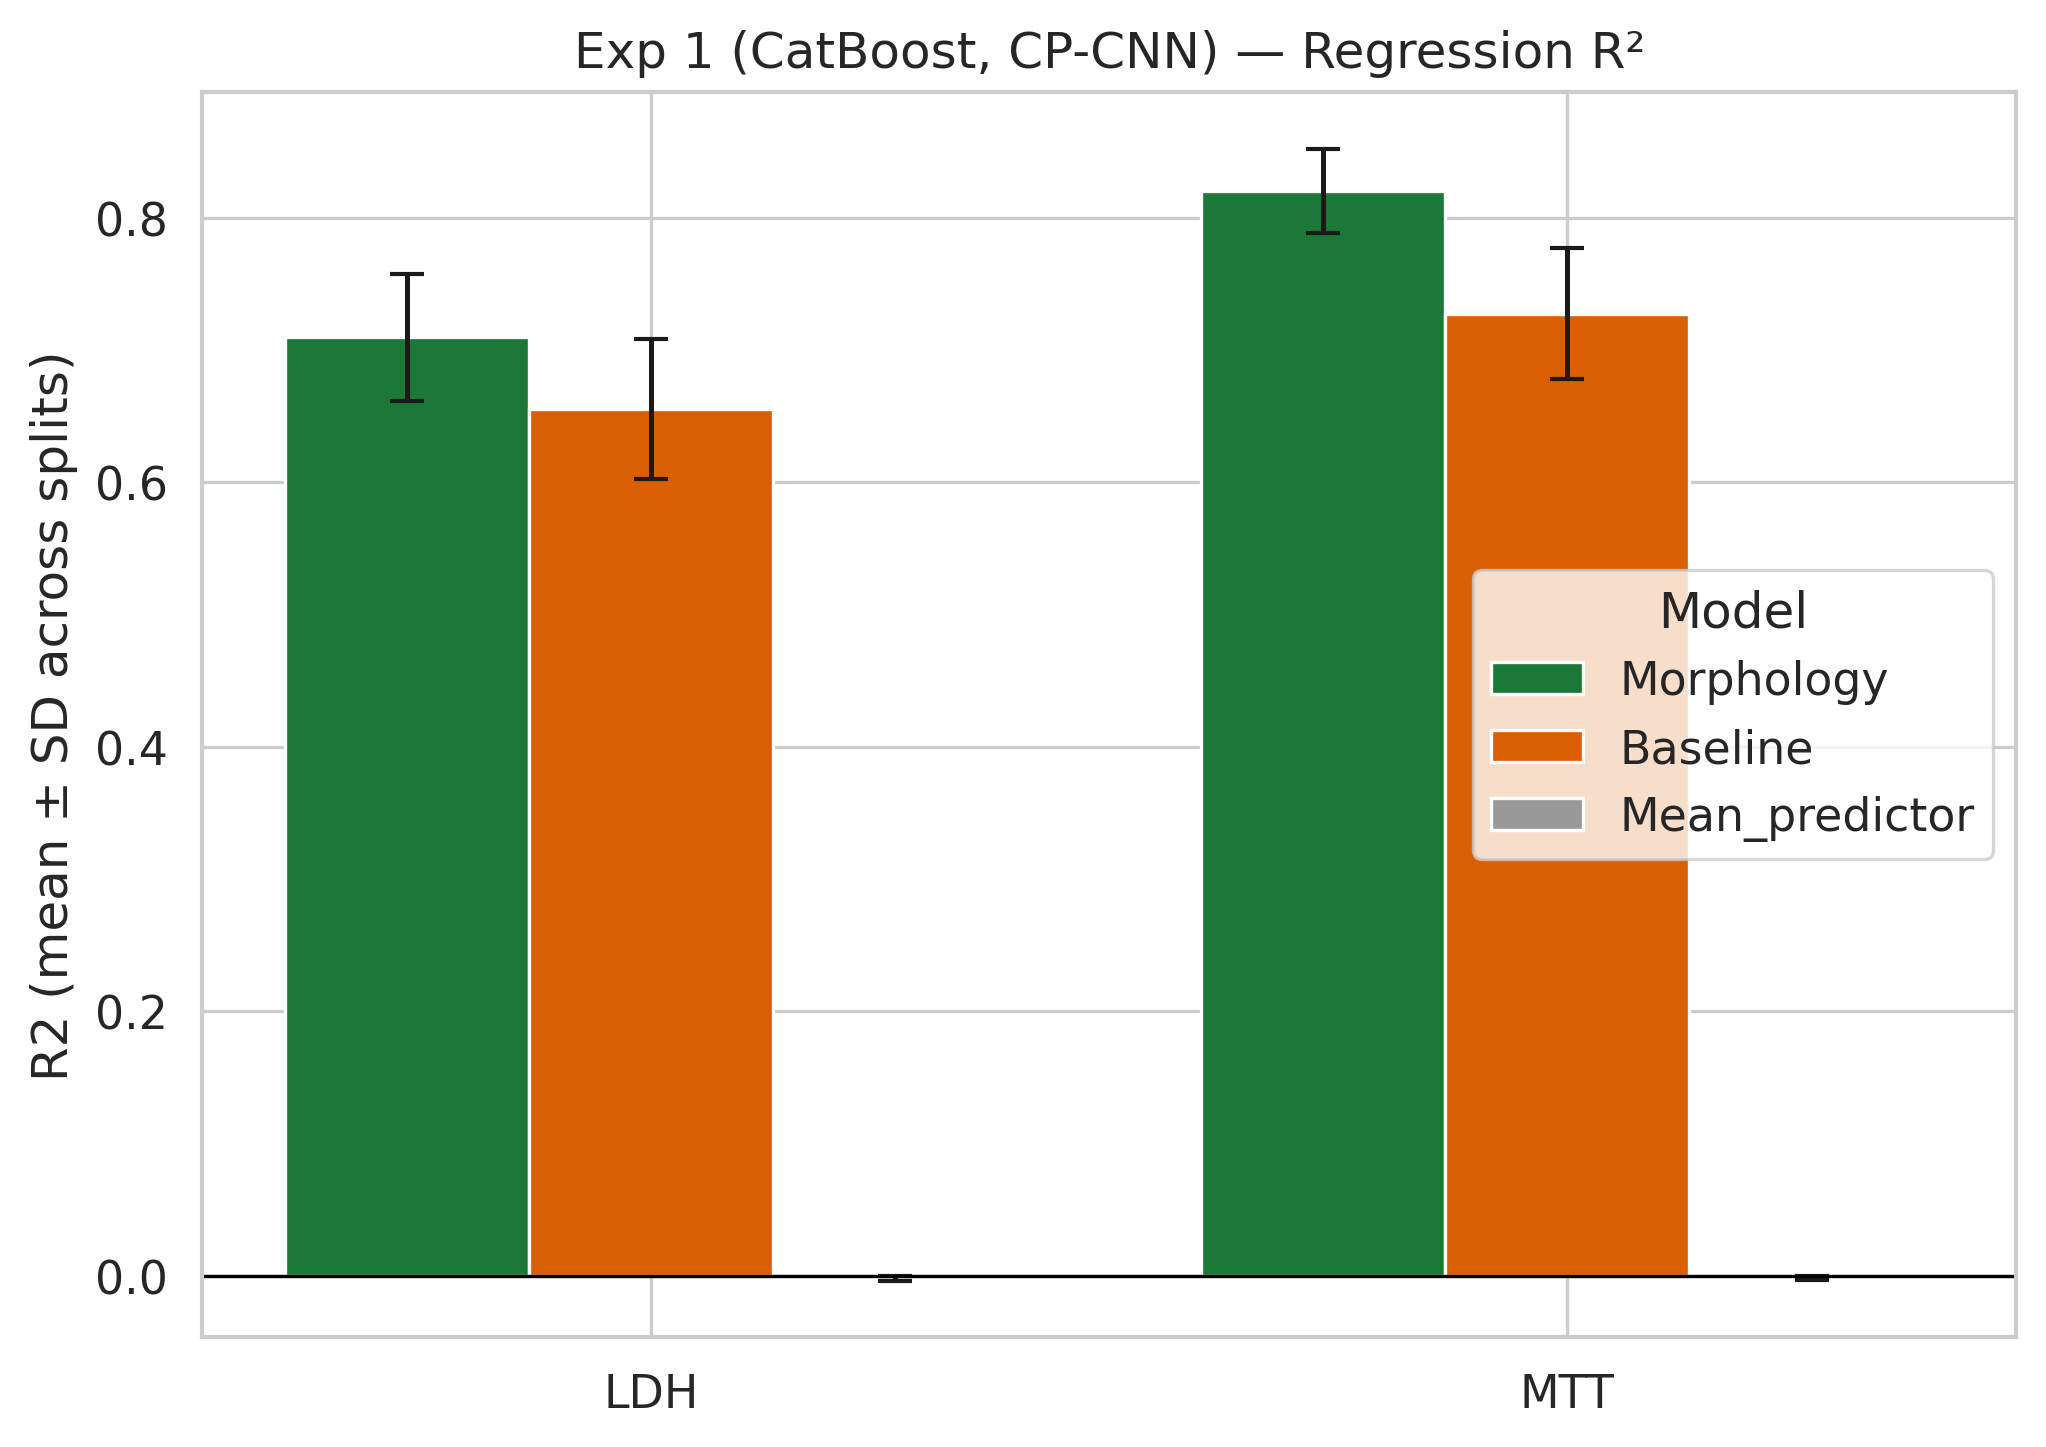

In [7]:
p = eu.plot_regression_metric(regression_summary, "R2", FIG / "regression_r2", "Exp 1 (CatBoost, CP-CNN) — Regression R²")
eu.show(p)


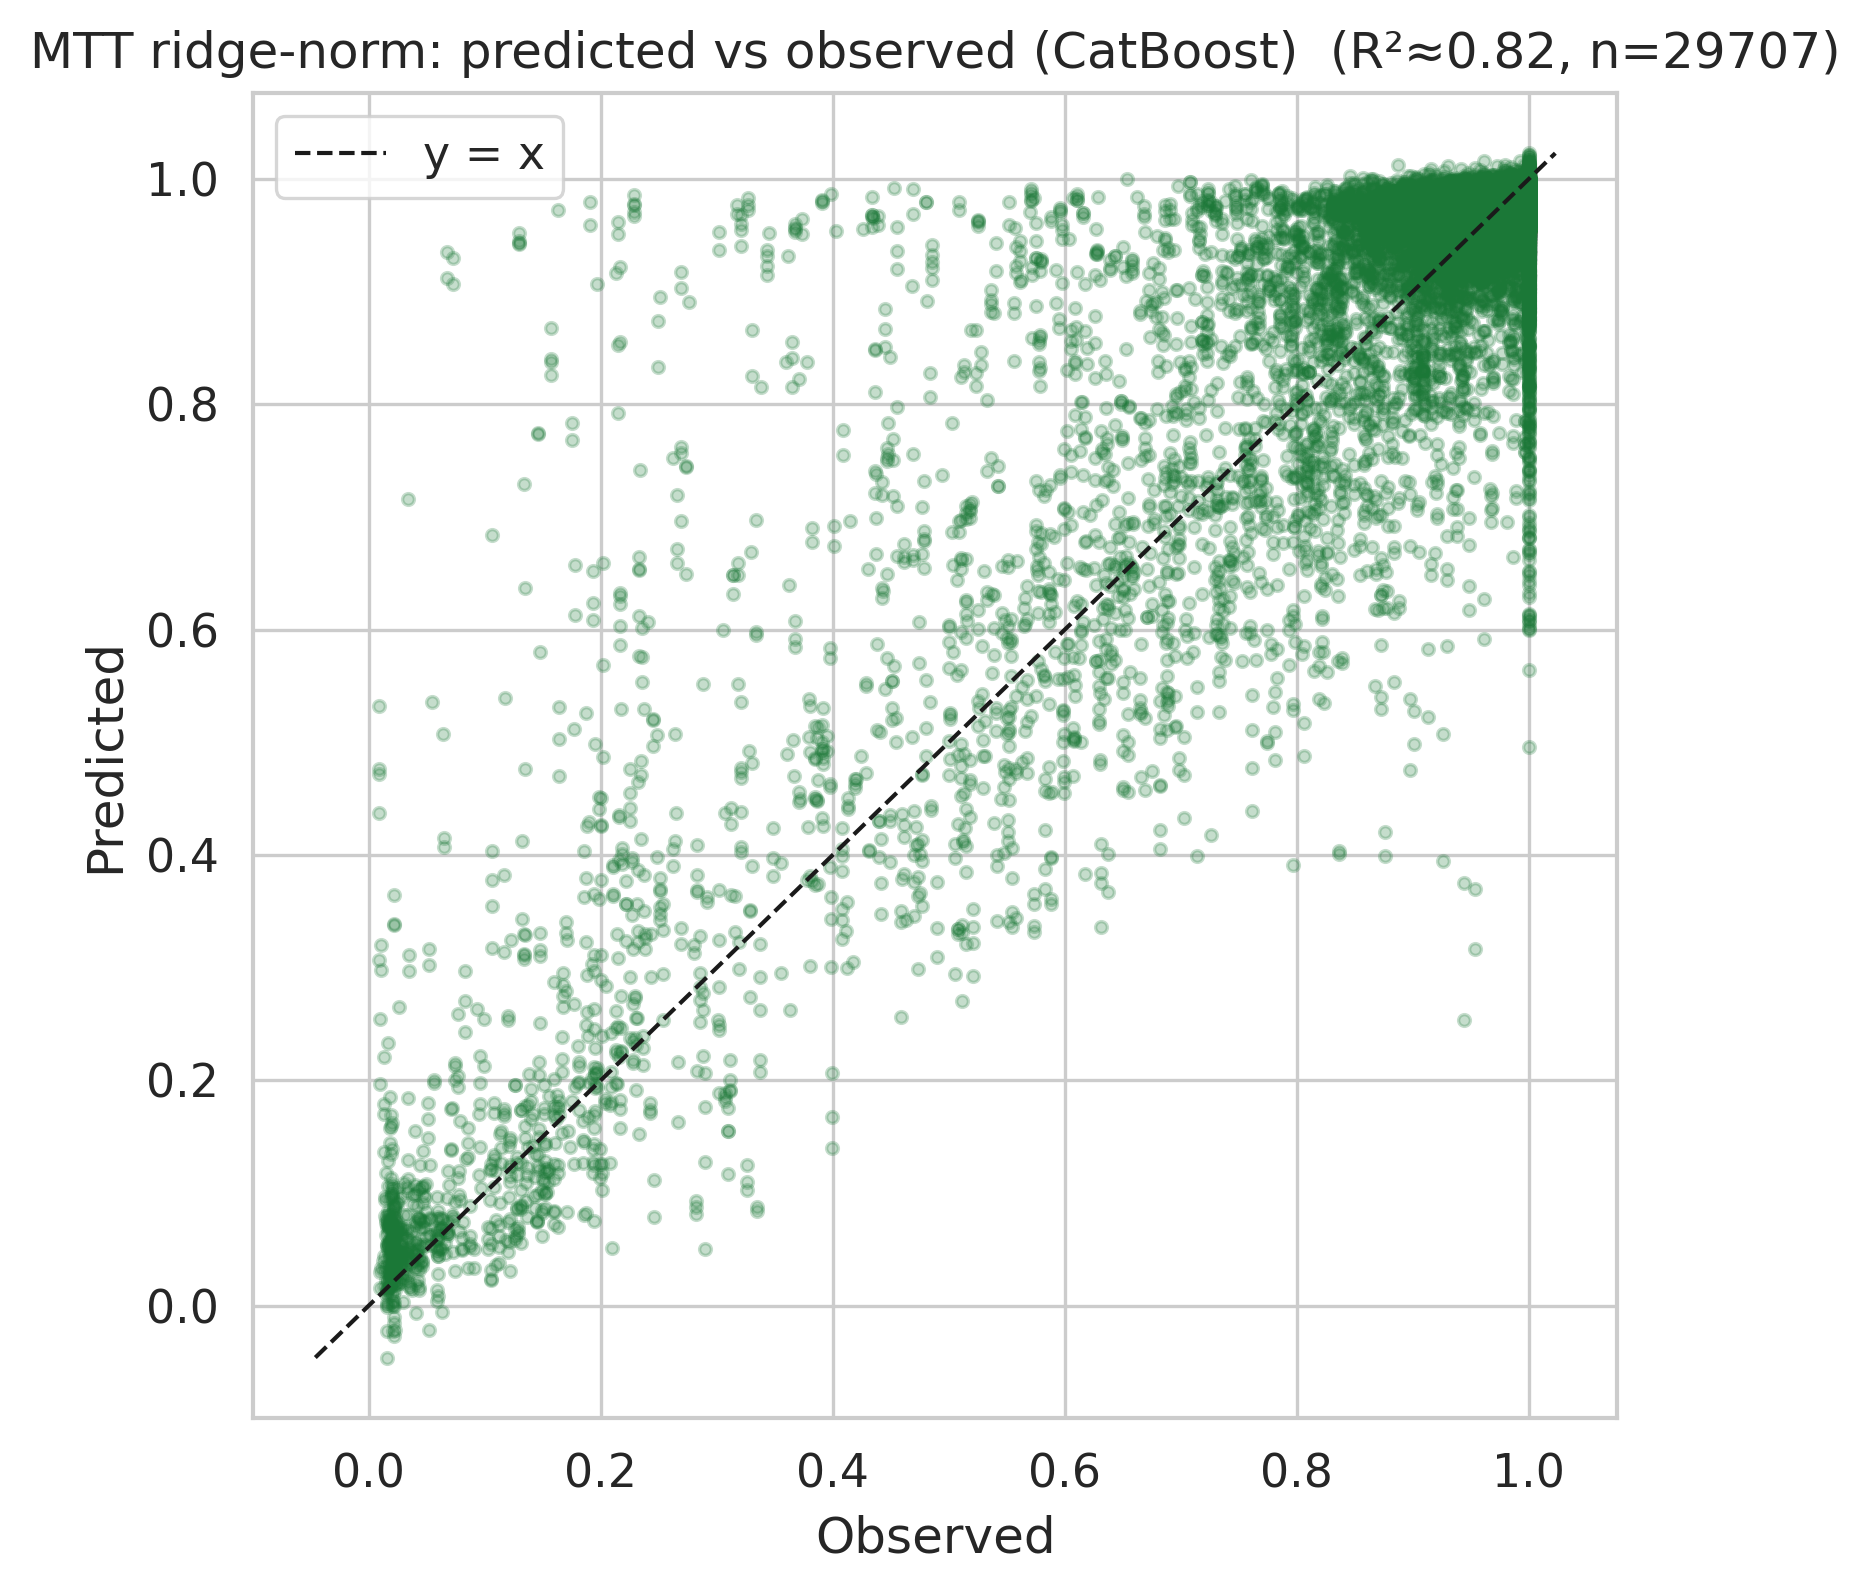

In [8]:
reg_pred = pl.read_parquet(axiom_cont_pred_path)
p = eu.plot_pred_vs_obs(reg_pred, "Metadata_mtt_ridge_norm", "Morphology", FIG / "pred_vs_obs_mtt", "MTT ridge-norm: predicted vs observed (CatBoost)")
eu.show(p)


### Head-to-head: baseline_0 (XGBoost) vs exp_1 (CatBoost)

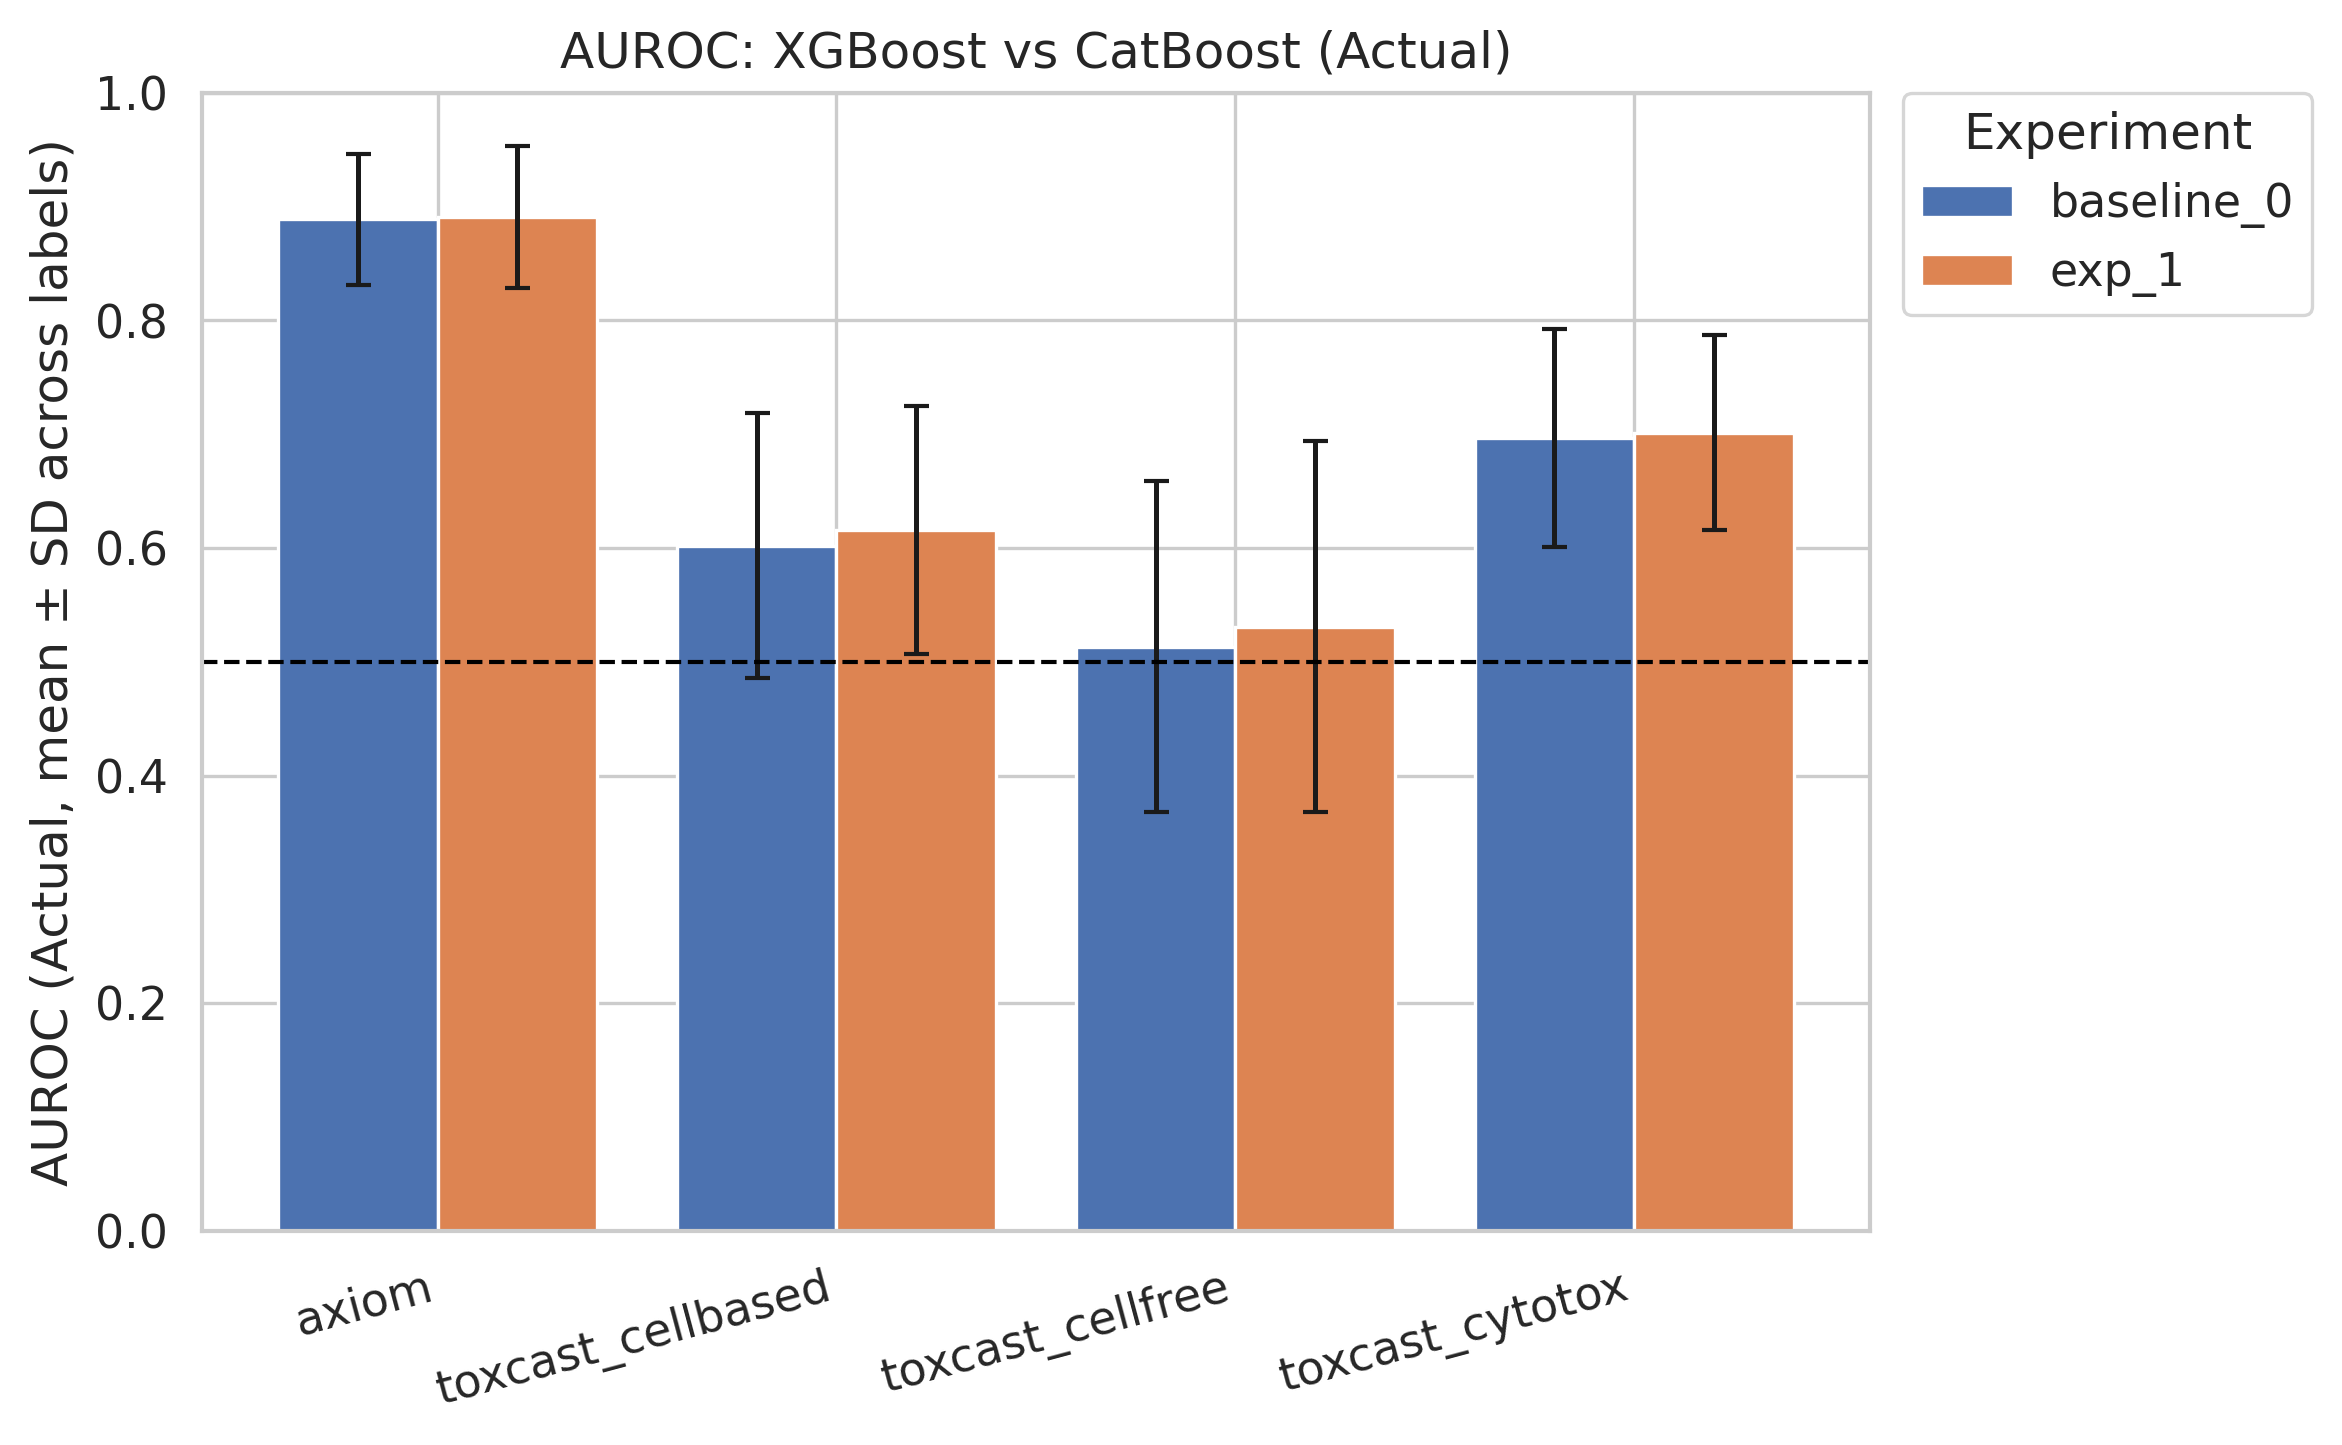

In [9]:
EXPERIMENTS = ["baseline_0", "exp_1"]

cm_multi = eu.load_classifier_metrics(*EXPERIMENTS)
p = eu.plot_experiment_comparison_auroc(cm_multi, FIG / "compare_auroc_xgb_vs_catboost", "AUROC: XGBoost vs CatBoost (Actual)")
eu.show(p)


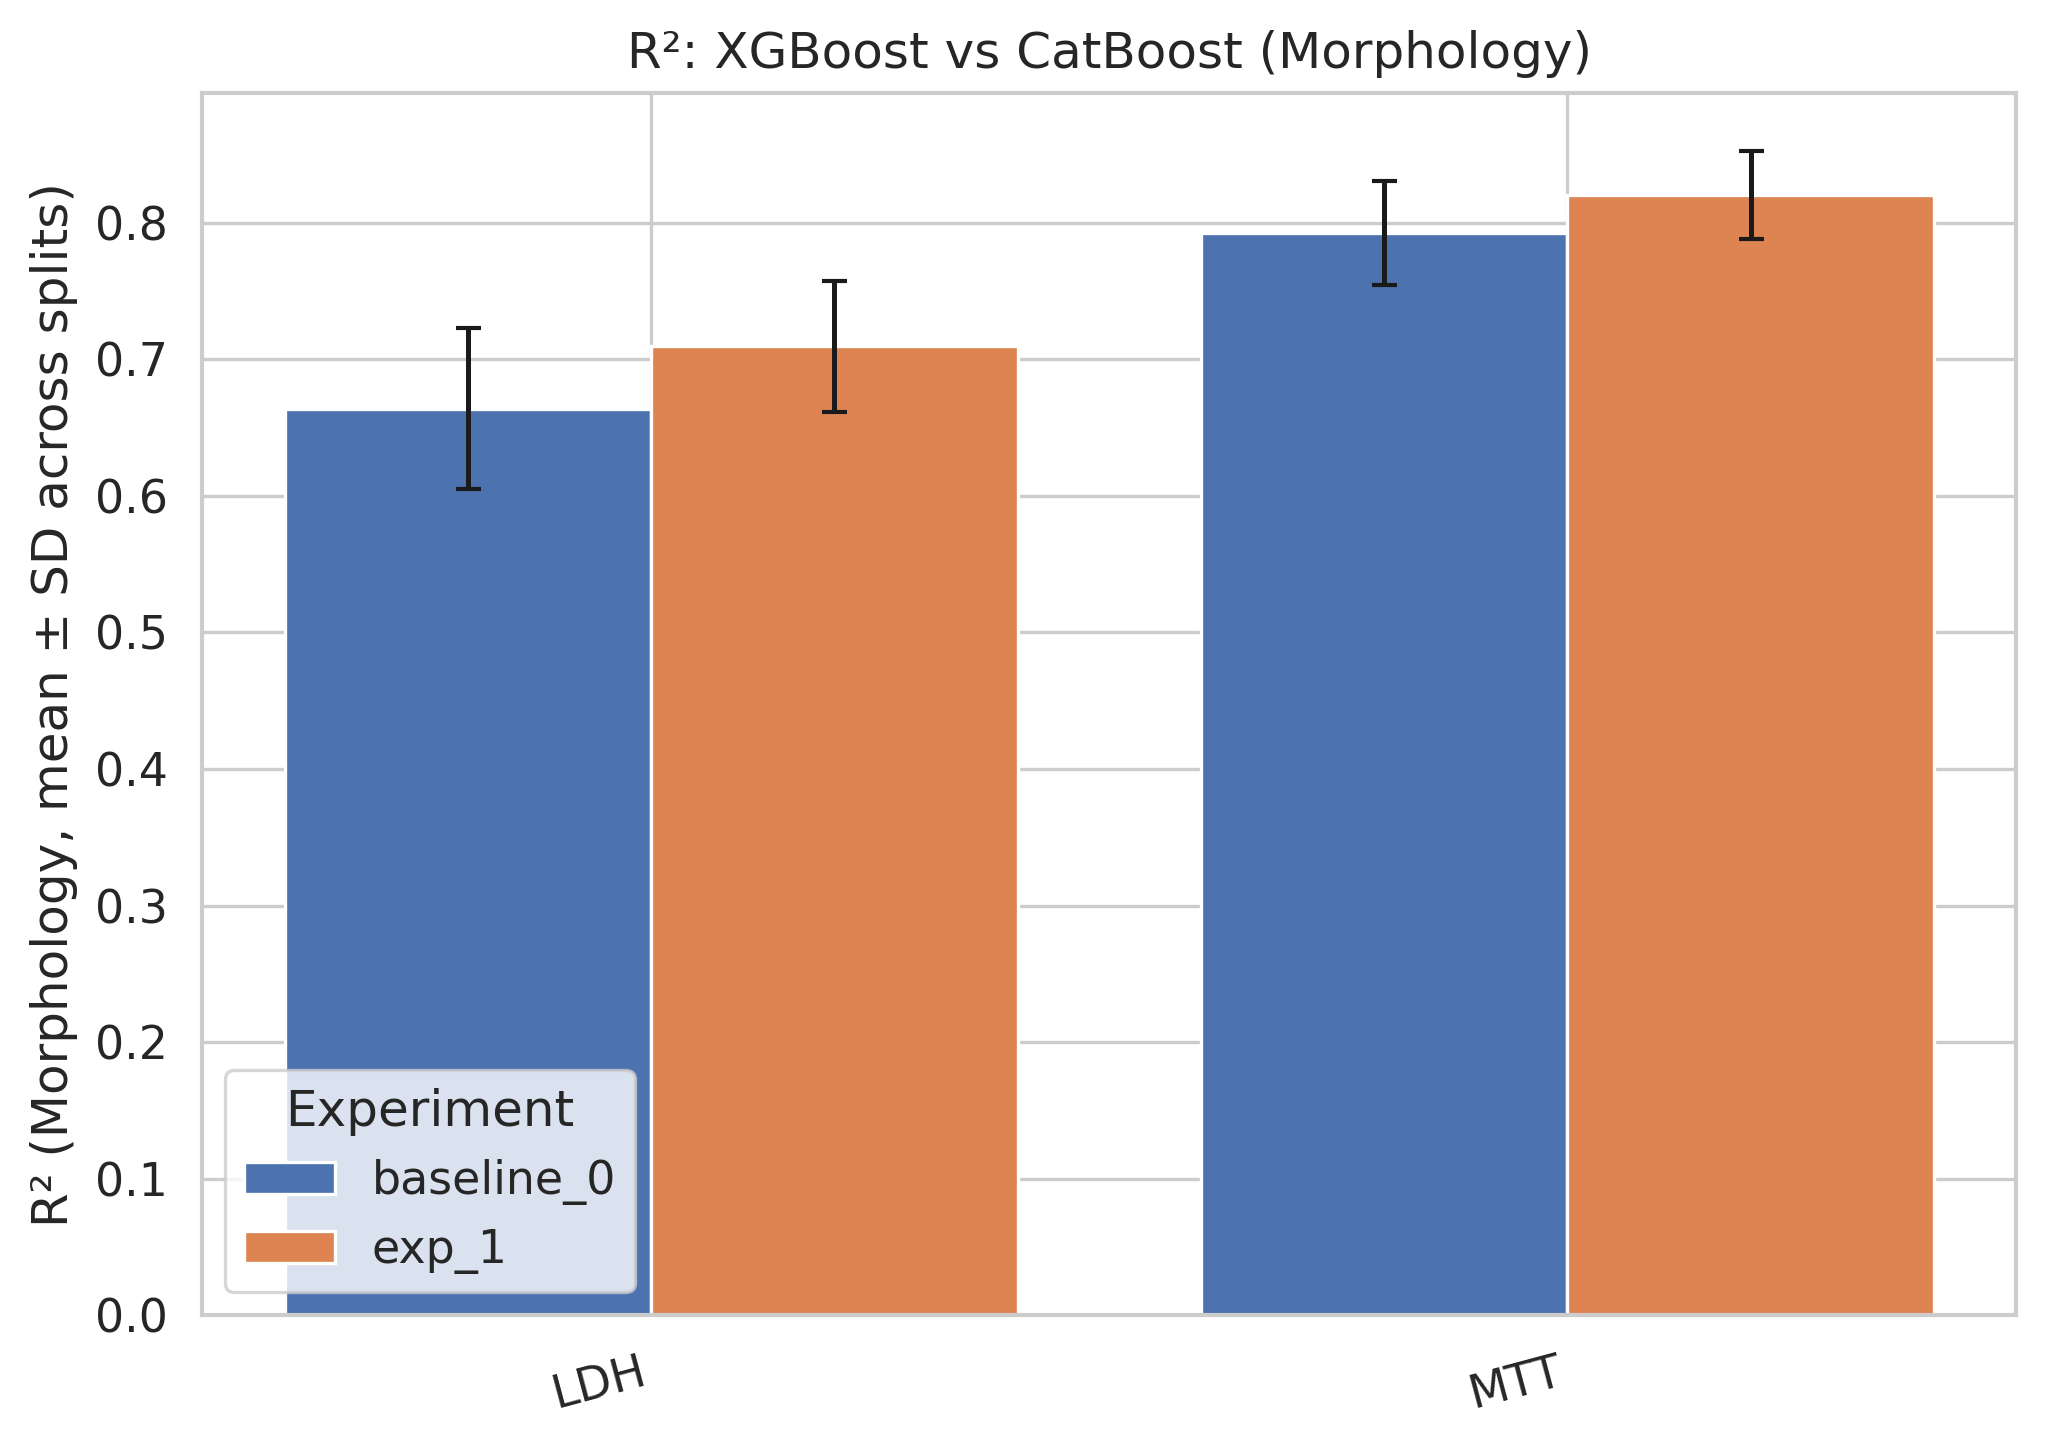

In [10]:
rm_multi = eu.load_regression_metrics(*EXPERIMENTS)
p = eu.plot_experiment_comparison_r2(rm_multi, FIG / "compare_r2_xgb_vs_catboost", "R²: XGBoost vs CatBoost (Morphology)")
eu.show(p)


## 5. Summary tables (dissertation-ready)

Same head-to-head data as the figures above, as tables — saved under
`3_experiments/outputs/exp_1/tables/` as both `.csv` (data/Excel) and a
`booktabs`-style `.tex` snippet ready to `\input{...}` directly into a LaTeX
document (needs `\usepackage{booktabs}` in the preamble). Built by
`experiment_utils.build_*_table` / `save_table`, so future experiments get the
same tables for free by adding their name to `EXPERIMENTS` above.

In [11]:
TABLES = EXP_OUT / "tables"

classifier_summary_table = eu.build_classifier_summary_table(cm_multi)
eu.save_table(classifier_summary_table, TABLES / "classifier_summary")
classifier_summary_table


,Outcome Type,Model,Experiment,AUROC,PRAUC
0,axiom,Actual,baseline_0,0.909068,0.793429
1,axiom,Actual,exp_1,0.912656,0.806607
2,axiom,Cellcount_baseline,baseline_0,0.724716,0.535050
3,axiom,Cellcount_baseline,exp_1,0.757893,0.574098
4,axiom,Random_baseline,baseline_0,0.484539,0.242551
5,axiom,Random_baseline,exp_1,0.489494,0.240361
6,toxcast_cellbased,Actual,baseline_0,0.595615,0.183560
7,toxcast_cellbased,Actual,exp_1,0.618675,0.193451
8,toxcast_cellbased,Cellcount_baseline,baseline_0,0.500167,0.132596
9,toxcast_cellbased,Cellcount_baseline,exp_1,0.500807,0.131886


In [12]:
axiom_labels_table = eu.build_axiom_label_table(cm_multi)
eu.save_table(axiom_labels_table, TABLES / "axiom_labels")
axiom_labels_table


,Label,Model,Experiment,AUROC,PRAUC
0,LDH,Actual,baseline_0,0.925928,0.721698
1,LDH,Actual,exp_1,0.930249,0.750693
2,LDH,Cellcount_baseline,baseline_0,0.730446,0.418538
3,LDH,Cellcount_baseline,exp_1,0.773964,0.457906
4,LDH,Random_baseline,baseline_0,0.491760,0.130230
5,LDH,Random_baseline,exp_1,0.468345,0.118985
6,MTT,Actual,baseline_0,0.866270,0.841494
7,MTT,Actual,exp_1,0.856837,0.829525
8,MTT,Cellcount_baseline,baseline_0,0.688028,0.635200
9,MTT,Cellcount_baseline,exp_1,0.698801,0.661168


In [13]:
regression_summary_table = eu.build_regression_summary_table(rm_multi)
eu.save_table(regression_summary_table, TABLES / "regression_summary")
regression_summary_table


,Target,Model,Experiment,R2,R2 SD,RMSE,MAE
0,LDH,Baseline,baseline_0,0.645670,0.043684,0.059701,0.034699
1,LDH,Baseline,exp_1,0.655511,0.052822,0.058783,0.035730
2,LDH,Mean_predictor,baseline_0,-0.002046,0.001966,0.100922,0.060572
3,LDH,Mean_predictor,exp_1,-0.002046,0.001966,0.100922,0.060572
4,LDH,Morphology,baseline_0,0.663890,0.058681,0.057782,0.039108
5,LDH,Morphology,exp_1,0.709644,0.048044,0.053757,0.036661
6,MTT,Baseline,baseline_0,0.698458,0.055239,0.092923,0.048279
7,MTT,Baseline,exp_1,0.727627,0.049557,0.088301,0.046364
8,MTT,Mean_predictor,baseline_0,-0.001910,0.001721,0.170990,0.091856
9,MTT,Mean_predictor,exp_1,-0.001910,0.001721,0.170990,0.091856


## Summary

`exp_1` (CatBoost) reference artifacts, saved under `3_experiments/outputs/exp_1/`:
- `metrics/exp_1_classifier_metrics.parquet`, `metrics/exp_1_regression_metrics.parquet` — same schema as baseline_0, computed by the same shared functions.
- `classifier_results/*.parquet` — raw pooled out-of-fold predictions, same schema as baseline_0's XGBoost predictions.
- `figures/*.{png,pdf}` — including the two head-to-head comparison figures against baseline_0.
- `tables/*.{csv,tex}` — dissertation-ready summary tables (classifier outcome-type summary, axiom per-label breakdown, regression summary), baseline_0 vs exp_1 side by side.

In [14]:
print("=== Classifier: XGBoost (baseline_0) vs CatBoost (exp_1), mean AUROC (Actual) ===")
print(
    cm_multi.filter(pl.col("Model_type") == "Actual")
    .group_by(["Outcome_type", "Experiment"])
    .agg(pl.col("AUROC").mean().round(3).alias("mean_AUROC"))
    .sort(["Outcome_type", "Experiment"])
)

print()
print("=== Regression: XGBoost (baseline_0) vs CatBoost (exp_1), R² (Morphology) ===")
print(
    rm_multi.filter(pl.col("Model_type") == "Morphology")
    .select(["Experiment", "Variable_Name", "R2_mean", "R2_std"])
    .sort(["Variable_Name", "Experiment"])
)


=== Classifier: XGBoost (baseline_0) vs CatBoost (exp_1), mean AUROC (Actual) ===
shape: (8, 3)
┌───────────────────┬────────────┬────────────┐
│ Outcome_type      ┆ Experiment ┆ mean_AUROC │
│ ---               ┆ ---        ┆ ---        │
│ str               ┆ str        ┆ f64        │
╞═══════════════════╪════════════╪════════════╡
│ axiom             ┆ baseline_0 ┆ 0.889      │
│ axiom             ┆ exp_1      ┆ 0.891      │
│ toxcast_cellbased ┆ baseline_0 ┆ 0.602      │
│ toxcast_cellbased ┆ exp_1      ┆ 0.616      │
│ toxcast_cellfree  ┆ baseline_0 ┆ 0.513      │
│ toxcast_cellfree  ┆ exp_1      ┆ 0.531      │
│ toxcast_cytotox   ┆ baseline_0 ┆ 0.696      │
│ toxcast_cytotox   ┆ exp_1      ┆ 0.701      │
└───────────────────┴────────────┴────────────┘

=== Regression: XGBoost (baseline_0) vs CatBoost (exp_1), R² (Morphology) ===
shape: (4, 4)
┌────────────┬─────────────────────────┬──────────┬──────────┐
│ Experiment ┆ Variable_Name           ┆ R2_mean  ┆ R2_std   │
│ ---        